<a href="https://colab.research.google.com/github/vsa282005/Memorial-de-Calculo-Trabalho-01-Vinicius-Da-Silva-Andrade-242004321/blob/main/Memorial_de_C%C3%A1lculo_Trabalho_01_Vin%C3%ADcius_Da_Silva_Andrade_242004321.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ANÁLISE ESTRUTURAL UNB - SUPORTE DO ROLETE (MEC. MATERIAIS II)
1. Escolha a Geometria (1-Atual, 2-Proposta, 3-Intermediaria): 1
2. Escolha a Condição de Carga (C1, C2, C3): C1
3. Digite a posição da seção x em mm (ex: 0 [Engaste A], 120, 300, 480): 480
4. Escolha o Ponto da seção (P0, P1, P2, P3, P4 ou CRITICO): P0
5. Digite o Diâmetro do eixo em mm (padrão 40): 40



 RELATÓRIO TÉCNICO DE VERIFICAÇÃO ESTRUTURAL
Geometria Selecionada:   ATUAL
Caso de Carregamento:    C1
Seção Transversal:       x = 480.0 mm
Ponto Avaliado:          P0 (y=0.0mm, z=0.0mm)
Diâmetro do Eixo:        40.0 mm
-----------------------------------------------------------------
Esforços Solicitantes Internos na Seção:
  - Força Normal (N):    +0.0 N
  - Momento Fletor (My): -144.00 N.m
  - Momento Fletor (Mz): -48.00 N.m
  - Torque (Tx):         -176.00 N.m
-----------------------------------------------------------------
Tensor de Tensões e Estado Principal:
  - Tensão Normal (sigma_x):     +0.00 MPa
  - Cisalhamento Resultante (tau):+1.34 MPa
  - Tensão Principal 1 (sigma_1): +1.34 MPa
  - Tensão Principal 2 (sigma_2): -1.34 MPa
  - Ângulo Principal (theta_p):  +45.00°
  - Cisalhamento Máx. Absoluto:  1.34 MPa
  - Tensão Equivalente von Mises: 2.32 MPa
-----------------------------------------------------------------
VERIFICAÇÃO DE SEGURANÇA (Requisito UnB: n >= 1.50):
  - 

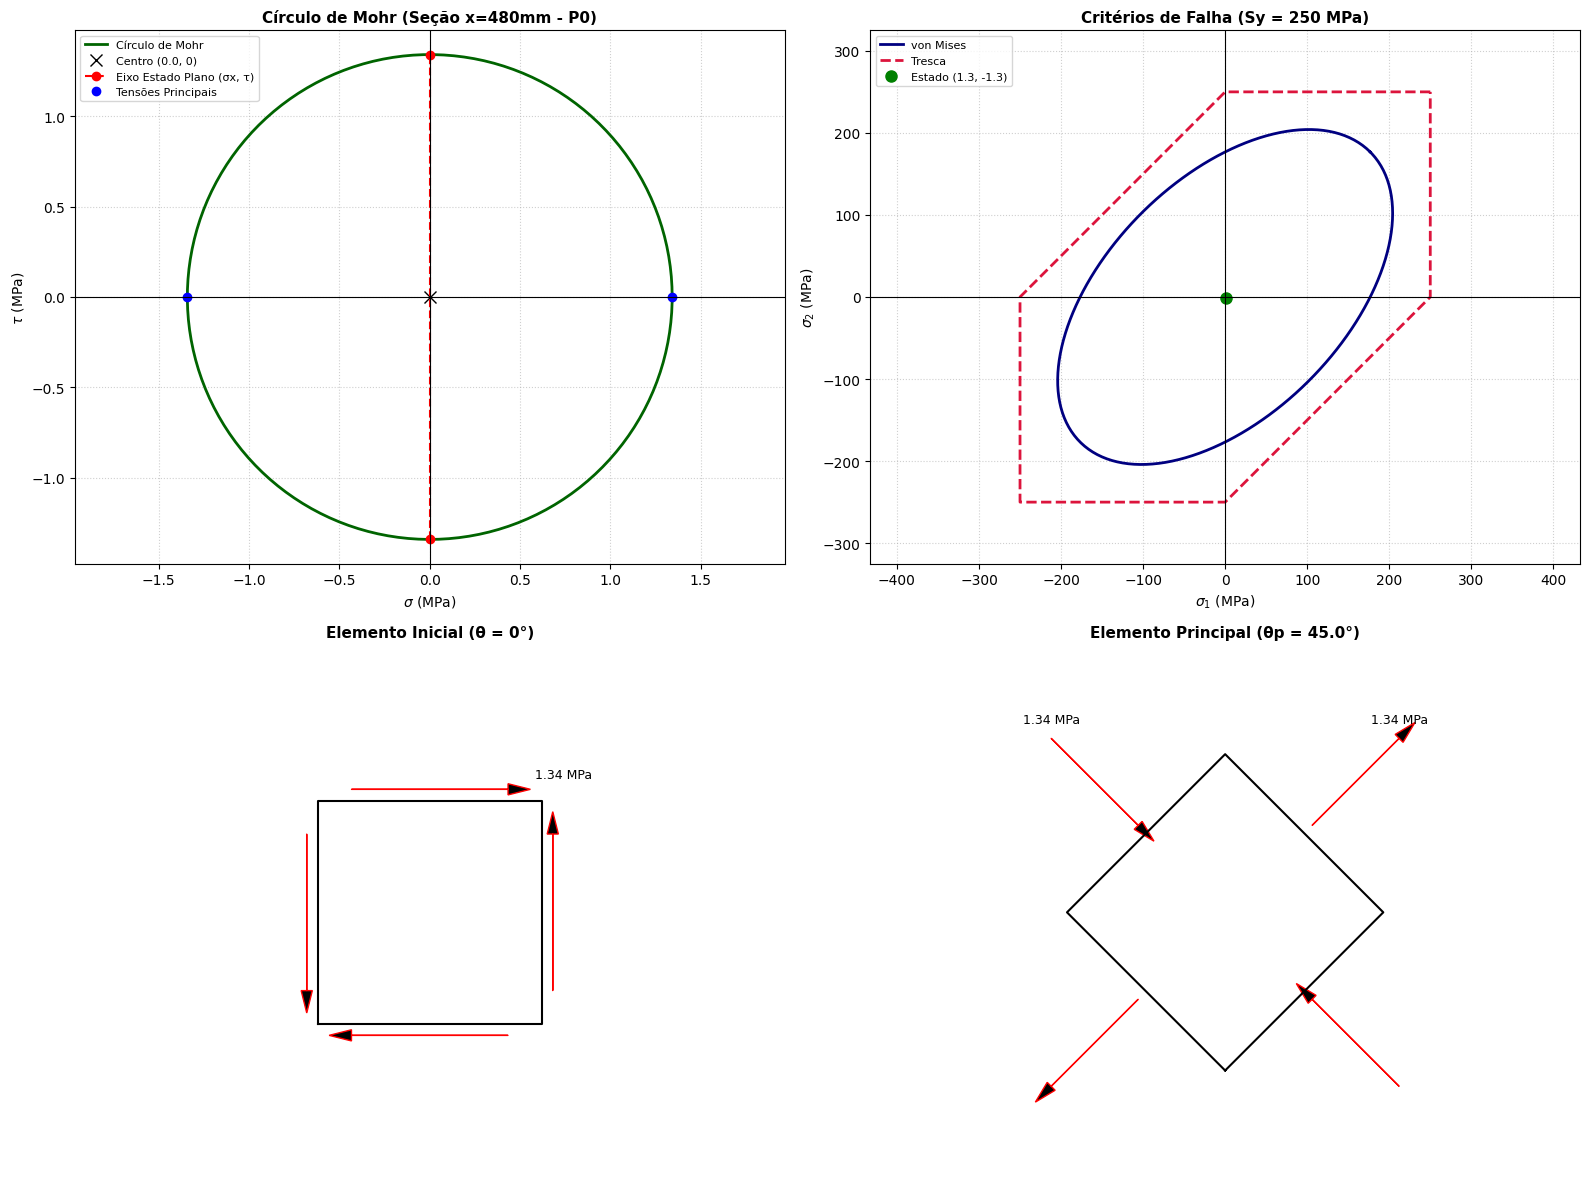

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Propriedades do Material e Projeto (Seção 1 e 5 do Documento)
Sy = 250e6             # Tensão de Escoamento ASTM A36 (Pa)
n_req = 1.50           # Fator de segurança requerido
sigma_adm = Sy / n_req  # Tensão admissível (166.67 MPa)

GEOMETRIAS = {
    '1': ('Atual', (0.600, 0.120, 0.080)),
    '2': ('Proposta', (0.600, 0.260, 0.180)),
    '3': ('Intermediaria', (0.600, 0.160, 0.180))
}

CARREGAMENTOS = {
    'C1': (0.0, 400.0, -1200.0),
    'C2': (600.0, -900.0, -1500.0),
    'C3': (-400.0, 700.0, -1600.0)
}

DIAMETROS_ALTERNATIVOS_MM = [40.0, 42.0, 45.0, 48.0]

def plota_tensao_plana_ax(ax, sigx, sigy, tauxy, ang_deg=0, titulo=""):
    x = np.array([[-1, -1], [1, -1], [1, 1.], [-1, 1], [-1, -1]])
    pts = np.array([[1.1, 0], [0, 1.1], [-1.1, 0], [0, -1.1],
                    [-.7, 1.1], [.7, -1.1], [1.1, -.7], [-1.1, .7]])
    ptext = np.array([[2.3, 0.1], [0.1, 2.3], [1.2, 1.2]])
    vec = np.array([[1.1, 0], [0, 1.1], [-1.1, 0], [0, -1.1],
                    [1.4, 0], [-1.4, 0], [0, 1.4], [0, -1.4]])

    theta = ang_deg * np.pi / 180.0
    tmat = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])

    x = np.matmul(x, tmat)
    pts = np.matmul(pts, tmat)
    ptext = np.matmul(ptext, tmat)
    vec = np.matmul(vec, tmat)

    hl, hw = 0.2, 0.1
    c1, c2 = 'k', 'r'
    hlx, hwx = hl, hw
    hly, hwy = hl, hw
    hlc, hwc = hl, hw

    if sigy < 0:
        pts[1, :] += vec[1, :]
        vec[1, :] = -vec[1, :]
        pts[3, :] += vec[3, :]
        vec[3, :] = -vec[3, :]
    elif np.isclose(sigy, 0):
        vec[1, :] = 0.
        vec[3, :] = 0.
        hly, hwy = 0., 0.

    if sigx < 0:
        pts[0, :] += vec[0, :]
        vec[0, :] = -vec[0, :]
        pts[2, :] += vec[2, :]
        vec[2, :] = -vec[2, :]
    elif np.isclose(sigx, 0):
        vec[0, :] = 0.
        vec[2, :] = 0.
        hlx, hwx = 0., 0.

    if tauxy < 0:
        pts[4:8, :] += vec[4:8, :]
        vec[4:8, :] = -vec[4:8, :]
    elif np.isclose(tauxy, 0):
        vec[4:8, :] = 0.
        hlc, hwc = 0., 0.

    if not np.isclose(sigx, 0):
        ax.text(ptext[0, 0], ptext[0, 1], f"{abs(sigx):.2f} MPa", fontsize=9, ha='center')
    if not np.isclose(sigy, 0):
        ax.text(ptext[1, 0], ptext[1, 1], f"{abs(sigy):.2f} MPa", fontsize=9, ha='center')
    if not np.isclose(tauxy, 0):
        ax.text(ptext[2, 0], ptext[2, 1], f"{abs(tauxy):.2f} MPa", fontsize=9, ha='center')

    ax.plot(x[:, 0], x[:, 1], 'k-', lw=1.5)
    ax.set_aspect('equal', adjustable='datalim')

    ax.arrow(pts[0,0], pts[0,1], vec[0,0], vec[0,1], head_width=hwx, head_length=hlx, fc=c1, ec=c2)
    ax.arrow(pts[2,0], pts[2,1], vec[2,0], vec[2,1], head_width=hwx, head_length=hlx, fc=c1, ec=c2)
    ax.arrow(pts[1,0], pts[1,1], vec[1,0], vec[1,1], head_width=hwy, head_length=hly, fc=c1, ec=c2)
    ax.arrow(pts[3,0], pts[3,1], vec[3,0], vec[3,1], head_width=hwy, head_length=hly, fc=c1, ec=c2)

    ax.arrow(pts[4,0], pts[4,1], vec[4,0], vec[4,1], head_width=hwc, head_length=hlc, fc=c1, ec=c2)
    ax.arrow(pts[5,0], pts[5,1], vec[5,0], vec[5,1], head_width=hwc, head_length=hlc, fc=c1, ec=c2)
    ax.arrow(pts[6,0], pts[6,1], vec[6,0], vec[6,1], head_width=hwc, head_length=hlc, fc=c1, ec=c2)
    ax.arrow(pts[7,0], pts[7,1], vec[7,0], vec[7,1], head_width=hwc, head_length=hlc, fc=c1, ec=c2)

    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-3.2, 3.2)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.axis('off')

def executar_analise_interativa():
    print("="*65)
    print(" ANÁLISE ESTRUTURAL UNB - SUPORTE DO ROLETE (MEC. MATERIAIS II)")
    print("="*65)

    # PASSO 1
    g_opt = input("1. Escolha a Geometria (1-Atual, 2-Proposta, 3-Intermediaria): ").strip()
    if g_opt not in GEOMETRIAS:
        g_opt = '2'
    geom_nome, (x_C, y_C, z_C) = GEOMETRIAS[g_opt]

    # PASSO 2
    c_opt = input("2. Escolha a Condição de Carga (C1, C2, C3): ").strip().upper()
    if c_opt not in CARREGAMENTOS:
        c_opt = 'C3'
    Fx, Fy, Fz = CARREGAMENTOS[c_opt]

    # PASSO 3
    try:
        x_mm = float(input("3. Digite a posição da seção x em mm (ex: 0 [Engaste A], 120, 300, 480): "))
    except ValueError:
        x_mm = 0.0  # Engaste A é o ponto de momento fletor máximo!

    # PASSO 4
    p_opt = input("4. Escolha o Ponto da seção (P0, P1, P2, P3, P4 ou CRITICO): ").strip().upper()
    if p_opt not in ['P0', 'P1', 'P2', 'P3', 'P4', 'CRITICO']:
        p_opt = 'P2'

    # PASSO 5
    try:
        D_mm = float(input("5. Digite o Diâmetro do eixo em mm (padrão 40): "))
    except ValueError:
        D_mm = 40.0

    # GEOMETRIA E PROPRIEDADES
    D = D_mm / 1000.0
    R = D / 2.0
    A = np.pi * R**2
    I = (np.pi * R**4) / 4.0
    J = (np.pi * R**4) / 2.0

    # COORDENADAS CORRIGIDAS SEGUNDO A TABELA DA UNB (SEÇÃO 4)
    pontos_coords = {
        'P0': (0.0, 0.0),       # Centro
        'P1': (+R, 0.0),       # Periferia Lateral (+y)
        'P2': (0.0, +R),       # Periferia Superior (+z)
        'P3': (-R, 0.0),       # Periferia Lateral Oposta (-y)
        'P4': (0.0, -R)        # Periferia Inferior (-z)
    }

    x = x_mm / 1000.0

    # ESFORÇOS INTERNOS SOLICITANTES NO EIXO (SEÇÃO 1 E 4)
    Tx = y_C * Fz - z_C * Fy
    N = Fx
    Vy = Fy
    Vz = Fz
    My = z_C * Fx + Fz * (0.600 - x)
    Mz = -y_C * Fx - Fy * (0.600 - x)

    # BUSCA DISCRETIZADA DO PONTO CRÍTICO NA PERIFERIA (SEÇÃO 4 DO EDITAL)
    if p_opt == 'CRITICO':
        thetas = np.linspace(0, 2*np.pi, 360)
        max_vm_periferia = -1.0
        best_yp, best_zp = 0.0, 0.0
        for th in thetas:
            y_temp = R * np.cos(th)
            z_temp = R * np.sin(th)
            sig_temp = (N / A) - (My * z_temp / I) + (Mz * y_temp / I)
            tau_xy_t = - (Tx * z_temp) / J
            tau_xz_t = (Tx * y_temp) / J
            tau_res_t = np.sqrt(tau_xy_t**2 + tau_xz_t**2)
            c_t = sig_temp / 2.0
            r_t = np.sqrt(c_t**2 + tau_res_t**2)
            s1_t, s2_t = c_t + r_t, c_t - r_t
            vm_t = np.sqrt(s1_t**2 - s1_t * s2_t + s2_t**2)
            if vm_t > max_vm_periferia:
                max_vm_periferia = vm_t
                best_yp, best_zp = y_temp, z_temp
        yp, zp = best_yp, best_zp
    else:
        yp, zp = pontos_coords[p_opt]

    # TENÇÃO NORMAL TOTAL (AXIAL + FLEXÃO DUPLA)
    sigma_x = (N / A) - (My * zp / I) + (Mz * yp / I)

    # TENSÕES DE CISALHAMENTO (JOURAWSKI VS TORÇÃO)
    if p_opt == 'P0':
        tau_xy = (4.0 * Vy) / (3.0 * A)
        tau_xz = (4.0 * Vz) / (3.0 * A)
    else:
        tau_xy = - (Tx * zp) / J
        tau_xz = (Tx * yp) / J

    tau_res = np.sqrt(tau_xy**2 + tau_xz**2)

    # CÍRCULO DE MOHR E TENSÕES PRINCIPAIS
    centro = sigma_x / 2.0
    raio_mohr = np.sqrt((sigma_x / 2.0)**2 + tau_res**2)

    sigma_1 = centro + raio_mohr
    sigma_2 = centro - raio_mohr
    tau_max_abs = max(abs(sigma_1 - sigma_2) / 2.0, abs(sigma_1) / 2.0, abs(sigma_2) / 2.0)
    sigma_vm = np.sqrt(sigma_1**2 - sigma_1 * sigma_2 + sigma_2**2)

    # ÂNGULO PRINCIPAL theta_p
    theta_p_deg = np.degrees(0.5 * np.arctan2(2.0 * tau_res, sigma_x))

    # FATORES DE SEGURANÇA E VERIFICAÇÃO DO REQUISITO (n >= 1.50)
    n_tresca = Sy / (2 * tau_max_abs) if tau_max_abs > 0 else np.inf
    n_vm = Sy / sigma_vm if sigma_vm > 0 else np.inf
    atende_requisito = n_vm >= n_req and n_tresca >= n_req

    # RELATÓRIO EXECUTIVO
    print("\n" + "="*65)
    print(" RELATÓRIO TÉCNICO DE VERIFICAÇÃO ESTRUTURAL")
    print("="*65)
    print(f"Geometria Selecionada:   {geom_nome.upper()}")
    print(f"Caso de Carregamento:    {c_opt}")
    print(f"Seção Transversal:       x = {x_mm:.1f} mm")
    print(f"Ponto Avaliado:          {p_opt} (y={yp*1000:.1f}mm, z={zp*1000:.1f}mm)")
    print(f"Diâmetro do Eixo:        {D_mm:.1f} mm")
    print("-" * 65)
    print("Esforços Solicitantes Internos na Seção:")
    print(f"  - Força Normal (N):    {N:+.1f} N")
    print(f"  - Momento Fletor (My): {My:+.2f} N.m")
    print(f"  - Momento Fletor (Mz): {Mz:+.2f} N.m")
    print(f"  - Torque (Tx):         {Tx:+.2f} N.m")
    print("-" * 65)
    print("Tensor de Tensões e Estado Principal:")
    print(f"  - Tensão Normal (sigma_x):     {sigma_x/1e6:+.2f} MPa")
    print(f"  - Cisalhamento Resultante (tau):{tau_res/1e6:+.2f} MPa")
    print(f"  - Tensão Principal 1 (sigma_1): {sigma_1/1e6:+.2f} MPa")
    print(f"  - Tensão Principal 2 (sigma_2): {sigma_2/1e6:+.2f} MPa")
    print(f"  - Ângulo Principal (theta_p):  {theta_p_deg:+.2f}°")
    print(f"  - Cisalhamento Máx. Absoluto:  {tau_max_abs/1e6:.2f} MPa")
    print(f"  - Tensão Equivalente von Mises: {sigma_vm/1e6:.2f} MPa")
    print("-" * 65)
    print(f"VERIFICAÇÃO DE SEGURANÇA (Requisito UnB: n >= 1.50):")
    print(f"  - Fator de Segurança (von Mises): n = {n_vm:.2f}")
    print(f"  - Fator de Segurança (Tresca):    n = {n_tresca:.2f}")

    if atende_requisito:
        print("  --> PARECER: APROVADO! O conjunto atende ao requisito de segurança.")
    else:
        print("  --> PARECER: REPROVADO! O eixo atual NÃO atende ao requisito de segurança.")
        # Busca automaticamente a alternativa de diâmetro recomendada (Seção 5)
        for d_alt in DIAMETROS_ALTERNATIVOS_MM:
            r_a = (d_alt / 1000.0) / 2.0
            a_a = np.pi * r_a**2
            i_a = (np.pi * r_a**4) / 4.0
            j_a = (np.pi * r_a**4) / 2.0
            sig_x_a = (N / a_a) - (My * zp / i_a) + (Mz * yp / i_a)
            tau_t_a = np.sqrt(((-Tx*zp)/j_a)**2 + ((Tx*yp)/j_a)**2) if p_opt != 'P0' else np.sqrt(((4*Vy)/(3*a_a))**2 + ((4*Vz)/(3*a_a))**2)
            c_a = sig_x_a / 2.0
            r_mohr_a = np.sqrt(c_a**2 + tau_t_a**2)
            s1_a, s2_a = c_a + r_mohr_a, c_a - r_mohr_a
            vm_a = np.sqrt(s1_a**2 - s1_a * s2_a + s2_a**2)
            n_vm_a = Sy / vm_a
            if n_vm_a >= n_req:
                print(f"  --> RECOMENDAÇÃO: Substituir pelo eixo de diâmetro D = {d_alt:.0f} mm (n_vonMises = {n_vm_a:.2f})")
                break
        else:
            print("  --> RECOMENDAÇÃO: Nenhum dos diâmetros alternativos (até 48mm) atende ao requisito!")

    print("="*65 + "\n")

    # PLOTAGEM DOS GRÁFICOS
    s1_mpa = sigma_1 / 1e6
    s2_mpa = sigma_2 / 1e6
    sx_mpa = sigma_x / 1e6
    tau_res_mpa = tau_res / 1e6
    centro_mpa = centro / 1e6
    raio_mpa = raio_mohr / 1e6
    Sy_mpa = Sy / 1e6

    fig = plt.figure(figsize=(16, 12))

    # 1. Círculo de Mohr
    ax1 = fig.add_subplot(2, 2, 1)
    angles = np.linspace(0, 2 * np.pi, 300)
    ax1.plot(centro_mpa + raio_mpa * np.cos(angles), raio_mpa * np.sin(angles), color='darkgreen', lw=2, label='Círculo de Mohr')
    ax1.plot(centro_mpa, 0, 'kx', markersize=8, label=f'Centro ({centro_mpa:.1f}, 0)')
    ax1.plot([sx_mpa, 0], [-tau_res_mpa, tau_res_mpa], 'r--o', label='Eixo Estado Plano (σx, τ)')
    ax1.plot([s1_mpa, s2_mpa], [0, 0], 'bo', label='Tensões Principais')
    ax1.axhline(0, color='black', linewidth=0.8)
    ax1.axvline(0, color='black', linewidth=0.8)
    ax1.set_aspect('equal', adjustable='datalim')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.set_xlabel(r'$\sigma$ (MPa)', fontsize=10)
    ax1.set_ylabel(r'$\tau$ (MPa)', fontsize=10)
    ax1.set_title(f'Círculo de Mohr (Seção x={x_mm:.0f}mm - {p_opt})', fontsize=11, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=8)

    # 2. Critérios de Falha
    ax2 = fig.add_subplot(2, 2, 2)
    theta = np.linspace(0, 2 * np.pi, 300)
    sA_vm, sB_vm = Sy_mpa * np.cos(theta), Sy_mpa * np.sin(theta)
    sA_plot = sA_vm * np.cos(np.pi/4) - sB_vm * np.sin(np.pi/4) / np.sqrt(3)
    sB_plot = sA_vm * np.sin(np.pi/4) + sB_vm * np.cos(np.pi/4) / np.sqrt(3)
    ax2.plot(sA_plot, sB_plot, label='von Mises', color='navy', lw=2)
    tresca_x = [Sy_mpa, 0, -Sy_mpa, -Sy_mpa, 0, Sy_mpa, Sy_mpa]
    tresca_y = [Sy_mpa, Sy_mpa, 0, -Sy_mpa, -Sy_mpa, 0, Sy_mpa]
    ax2.plot(tresca_x, tresca_y, label='Tresca', color='crimson', linestyle='--', lw=2)
    ax2.plot(s1_mpa, s2_mpa, 'go', markersize=8, label=f'Estado ({s1_mpa:.1f}, {s2_mpa:.1f})')

    limite = max(Sy_mpa * 1.3, abs(s1_mpa) * 1.2, abs(s2_mpa) * 1.2)
    ax2.set_xlim(-limite, limite)
    ax2.set_ylim(-limite, limite)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.axvline(0, color='black', linewidth=0.8)
    ax2.set_aspect('equal', adjustable='datalim')
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.set_xlabel(r'$\sigma_1$ (MPa)', fontsize=10)
    ax2.set_ylabel(r'$\sigma_2$ (MPa)', fontsize=10)
    ax2.set_title(f'Critérios de Falha (Sy = {Sy_mpa:.0f} MPa)', fontsize=11, fontweight='bold')
    ax2.legend(loc='upper left', fontsize=8)

    # 3. Elemento Inicial (θ = 0°)
    ax3 = fig.add_subplot(2, 2, 3)
    plota_tensao_plana_ax(ax3, sx_mpa, 0.0, tau_res_mpa, ang_deg=0, titulo="Elemento Inicial (θ = 0°)")

    # 4. Elemento Principal (θ = θp)
    ax4 = fig.add_subplot(2, 2, 4)
    plota_tensao_plana_ax(ax4, s1_mpa, s2_mpa, 0.0, ang_deg=theta_p_deg, titulo=f"Elemento Principal (θp = {theta_p_deg:.1f}°)")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    executar_analise_interativa()